# Data Quality Control: current experiment design

Per-subject data quality for the current version of the experiment (six
clock-face arrangements, `POSITION_LABELS` scheme, same as
`scripts/attentional_spatial_bias.ipynb`).

Supersedes `scripts/data_evaluation.ipynb`, which was written for an older,
incompatible position scheme. That notebook is left as-is.

**Subjects:** 16 full 48-trial recordings in `data/raw/` (43, 44, 51, 52,
54, 60, 61, 62, 63, 101, 102, 103, 104, 105, 106, 107). LTR/RTL group is
read straight from each subject's CSV (`GROUPS`, Section 1) rather than
hand-maintained here.

## 1. Setup and configuration

In [1]:
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

In [2]:
DATA_DIR = "../data/raw"
SUBJECTS = ["subject-43", "subject-44", "subject-51", "subject-52", "subject-54", "subject-60", "subject-61", "subject-62", "subject-63",
            "subject-101", "subject-102", "subject-103", "subject-104", "subject-105",
            "subject-106", "subject-107"]
GROUP_COLORS = {"LTR": "#1f77b4", "RTL": "#d62728"}

OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

SCREEN_W, SCREEN_H = 1920, 1080
AOI_MARGIN_PX = 150   # square AOI half-width, matches the experiment's online detection

MIN_LATENCY_MS = 80      # anticipatory-fixation floor (the only latency exclusion)
SLOW_REF_MS = 2000       # fast/slow boundary drawn on the boxplots, reference only

POSITION_LABELS = {
    "1": (9, 3), "2": (10, 4), "3": (11, 5),
    "4": (12, 6), "5": (7, 1), "6": (8, 2),
}


def load_tsv(subj):
    path = os.path.join(DATA_DIR, subj + ".tsv")
    df = pd.read_csv(path, sep="\t")
    df.replace(["NA", "undefined"], np.nan, inplace=True)
    num_cols = ["TIME", "FPOGX", "FPOGY", "FPOGS", "FPOGD", "FPOGID", "FPOGV",
                "BPOGX", "BPOGY", "BPOGV"]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.sort_values("TIME").reset_index(drop=True)
    return df


def load_csv(subj):
    path = os.path.join(DATA_DIR, subj + ".csv")
    df = pd.read_csv(path, dtype=str)
    for c in ["trial_nr", "x_left", "y_left", "x_right", "y_right"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["subject_nr"] = df["subject_nr"].astype(str)
    return df


tsv_data = {s: load_tsv(s) for s in SUBJECTS}
csv_data = {s: load_csv(s) for s in SUBJECTS}

# Read straight from each subject's own CSV rather than hand-maintaining a
# lookup table -- avoids this drifting out of sync when subjects are added.
GROUPS = {s: csv_data[s]["group"].iloc[0] for s in SUBJECTS}

print({s: (len(tsv_data[s]), len(csv_data[s])) for s in SUBJECTS})
print(GROUPS)

/var/folders/hc/vc9rr5rd1fs_7455sz276swh0000gn/T/ipykernel_67483/191030158.py:24: DtypeWarning: Columns (0: USER) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, sep="\t")


{'subject-43': (105315, 48), 'subject-44': (100907, 48), 'subject-51': (77553, 48), 'subject-52': (71196, 48), 'subject-54': (78804, 48), 'subject-60': (85983, 48), 'subject-61': (93061, 48), 'subject-62': (61455, 48), 'subject-63': (71074, 48), 'subject-101': (88757, 48), 'subject-102': (83448, 48), 'subject-103': (80217, 48), 'subject-104': (80945, 48), 'subject-105': (76859, 48), 'subject-106': (95507, 48), 'subject-107': (83802, 48)}
{'subject-43': 'LTR', 'subject-44': 'RTL', 'subject-51': 'LTR', 'subject-52': 'RTL', 'subject-54': 'RTL', 'subject-60': 'LTR', 'subject-61': 'RTL', 'subject-62': 'LTR', 'subject-63': 'LTR', 'subject-101': 'LTR', 'subject-102': 'LTR', 'subject-103': 'RTL', 'subject-104': 'LTR', 'subject-105': 'LTR', 'subject-106': 'LTR', 'subject-107': 'LTR'}


## 2. Marker & trial integrity

Each recording should have exactly 48 of `STIMULUS_ONSET`, `IMAGE_OFFSET`,
`FIXATION_POINT_START`, `FIXATION_POINT_END` in `USER`, and 48 CSV trial
rows. `MSG FIXATION_ONSET` is counted just for reference; the fixation-dot
window used later is `FIXATION_POINT_START` to `FIXATION_POINT_END`.

In [3]:
def count_marker(df, needle):
    u = df["USER"]
    mask = u.notna() & u.astype(str).str.contains(needle, na=False)
    return int(mask.sum())


rows = []
for s in SUBJECTS:
    tsv = tsv_data[s]
    n_onset = count_marker(tsv, "STIMULUS_ONSET")
    n_offset = count_marker(tsv, "IMAGE_OFFSET")
    n_fix_start = count_marker(tsv, "FIXATION_POINT_START")
    n_fix_end = count_marker(tsv, "FIXATION_POINT_END")
    n_fix_onset_msg = count_marker(tsv, "MSG FIXATION_ONSET")
    n_trials = len(csv_data[s])
    ok = (n_onset == 48 and n_offset == 48 and n_fix_start == 48
          and n_fix_end == 48 and n_trials == 48)
    rows.append(dict(subject=s, STIMULUS_ONSET=n_onset, IMAGE_OFFSET=n_offset,
                      FIXATION_POINT_START=n_fix_start, FIXATION_POINT_END=n_fix_end,
                      MSG_FIXATION_ONSET=n_fix_onset_msg, csv_trials=n_trials,
                      status="OK" if ok else "PROBLEM"))

marker_table = pd.DataFrame(rows)
marker_table

,subject,STIMULUS_ONSET,IMAGE_OFFSET,FIXATION_POINT_START,FIXATION_POINT_END,MSG_FIXATION_ONSET,csv_trials,status
0,subject-43,48,48,48,48,48,48,OK
1,subject-44,48,48,48,48,48,48,OK
2,subject-51,48,48,48,48,48,48,OK
3,subject-52,48,48,48,48,48,48,OK
4,subject-54,48,48,48,48,48,48,OK
5,subject-60,48,48,48,48,48,48,OK
6,subject-61,48,48,48,48,48,48,OK
7,subject-62,48,48,48,48,48,48,OK
8,subject-63,48,48,48,48,47,48,OK
9,subject-101,48,48,48,48,48,48,OK


In [4]:
# Per-trial image display duration: STIMULUS_ONSET -> next IMAGE_OFFSET
def onset_offset_durations(subj):
    tsv = tsv_data[subj]
    u = tsv["USER"].astype(str)
    onsets = tsv.loc[tsv["USER"].notna() & u.str.contains("STIMULUS_ONSET", na=False), "TIME"].values
    offsets = tsv.loc[tsv["USER"].notna() & u.str.contains("IMAGE_OFFSET", na=False), "TIME"].values
    durs = []
    for t0 in onsets:
        later = offsets[offsets > t0]
        if len(later):
            durs.append(later[0] - t0)
        else:
            durs.append(np.nan)
    return np.array(durs)


duration_summary = []
trial_durations = {}
for s in SUBJECTS:
    d = onset_offset_durations(s)
    trial_durations[s] = d
    n_flagged = int(np.sum((d < 4.5) | (d > 5.5)))
    duration_summary.append({
        "subject": s, "n_trials": len(d), "mean_s": np.nanmean(d),
        "min_s": np.nanmin(d), "max_s": np.nanmax(d),
        "n_outside_4.5_5.5s": n_flagged,
    })

duration_table = pd.DataFrame(duration_summary)
duration_table

,subject,n_trials,mean_s,min_s,max_s,n_outside_4.5_5.5s
0,subject-43,48,6.757743,5.02368,10.02069,19
1,subject-44,48,6.983456,5.02368,10.02722,22
2,subject-51,48,5.003475,4.99658,5.01025,0
3,subject-52,48,5.003709,4.99682,5.01037,0
4,subject-54,48,5.002736,4.99658,5.01075,0
5,subject-60,48,5.003786,4.99658,5.01055,0
6,subject-61,48,5.003234,4.99664,5.01047,0
7,subject-62,48,5.002035,4.99643,5.01024,0
8,subject-63,48,5.003299,4.99671,5.01038,0
9,subject-101,48,5.002501,4.99658,5.01062,0


## 3. Sampling quality per subject

Over the whole recording: effective sampling rate (median `TIME` interval),
share of gaps > 50 ms, share of valid `FPOGV`/`BPOGV` samples, and share of
`BPOG` samples with in-range coordinates.

In [5]:
sampling_rows = []
for s in SUBJECTS:
    tsv = tsv_data[s]
    dt = np.diff(tsv["TIME"].dropna().values)
    dt = dt[dt > 0]
    median_dt = np.median(dt)
    eff_hz = 1.0 / median_dt if median_dt > 0 else np.nan
    pct_gaps = 100.0 * np.mean(dt > 0.05)

    pct_fpogv = 100.0 * tsv["FPOGV"].mean()
    pct_bpogv = 100.0 * tsv["BPOGV"].mean()

    in_range = tsv["BPOGX"].between(0, 1) & tsv["BPOGY"].between(0, 1)
    pct_bpog_in_range = 100.0 * in_range.mean()

    sampling_rows.append(dict(subject=s, eff_sampling_hz=eff_hz, pct_gaps_gt_50ms=pct_gaps,
                               pct_fpogv_valid=pct_fpogv, pct_bpogv_valid=pct_bpogv,
                               pct_bpog_in_range=pct_bpog_in_range))

sampling_table = pd.DataFrame(sampling_rows)
sampling_table

,subject,eff_sampling_hz,pct_gaps_gt_50ms,pct_fpogv_valid,pct_bpogv_valid,pct_bpog_in_range
0,subject-43,149.031297,0.013294,83.348051,90.640460,93.449176
1,subject-44,149.031297,0.007928,86.959279,94.367090,90.364395
2,subject-51,149.031297,0.000000,74.206027,83.897464,81.594522
3,subject-52,149.031297,0.000000,78.160290,90.276139,84.230856
4,subject-54,146.412884,0.000000,86.118725,96.085224,94.045988
5,subject-60,149.031297,0.000000,82.955933,93.512671,91.038926
6,subject-61,149.031297,0.000000,84.975446,92.602701,87.028938
7,subject-62,149.253731,0.000000,83.758848,97.248393,95.728582
8,subject-63,149.031297,0.000000,84.614627,96.972170,89.952725
9,subject-101,149.031297,0.000000,85.702536,97.890871,91.309981


## 4. Fixation-dot accuracy & precision (calibration proxy)

Per trial, using valid `BPOG` samples during the central fixation dot
(`FIXATION_POINT_START` → `FIXATION_POINT_END`, dot at screen center):

- accuracy: mean distance (px) of samples from screen center
- precision: RMS deviation (px) from the trial's own mean gaze position

A proxy for calibration drift over the recording, not a full validation.

In [6]:
def fixation_dot_windows(subj):
    tsv = tsv_data[subj]
    u = tsv["USER"].astype(str)
    starts = tsv.loc[tsv["USER"].notna() & u.str.contains("FIXATION_POINT_START", na=False), "TIME"].values
    ends = tsv.loc[tsv["USER"].notna() & u.str.contains("FIXATION_POINT_END", na=False), "TIME"].values
    windows = []
    for t0 in starts:
        later = ends[ends > t0]
        t1 = later[0] if len(later) else t0 + 2.0
        windows.append((t0, t1))
    return windows


cx, cy = SCREEN_W / 2.0, SCREEN_H / 2.0

fixdot_rows = {}
for s in SUBJECTS:
    tsv = tsv_data[s]
    windows = fixation_dot_windows(s)
    trial_stats = []
    for i, (t0, t1) in enumerate(windows, start=1):
        win = tsv[(tsv["TIME"] >= t0) & (tsv["TIME"] <= t1) & (tsv["BPOGV"] == 1)
                  & tsv["BPOGX"].between(0, 1) & tsv["BPOGY"].between(0, 1)]
        if len(win) == 0:
            trial_stats.append(dict(trial=i, n_samples=0, accuracy_px=np.nan, precision_px=np.nan))
            continue
        x = win["BPOGX"].values * SCREEN_W
        y = win["BPOGY"].values * SCREEN_H
        acc = np.mean(np.hypot(x - cx, y - cy))
        mx, my = x.mean(), y.mean()
        prec = np.sqrt(np.mean((x - mx) ** 2 + (y - my) ** 2))
        trial_stats.append(dict(trial=i, n_samples=len(win), accuracy_px=acc, precision_px=prec))
    fixdot_rows[s] = pd.DataFrame(trial_stats)

fixdot_summary = []
for s in SUBJECTS:
    df = fixdot_rows[s]
    fixdot_summary.append(dict(
        subject=s, n_trials=len(df),
        median_accuracy_px=df["accuracy_px"].median(),
        median_precision_px=df["precision_px"].median(),
        n_accuracy_gt_100px=int((df["accuracy_px"] > 100).sum()),
    ))

fixdot_summary_table = pd.DataFrame(fixdot_summary)
fixdot_summary_table

,subject,n_trials,median_accuracy_px,median_precision_px,n_accuracy_gt_100px
0,subject-43,48,93.184269,119.211176,20
1,subject-44,48,50.848157,64.208107,5
2,subject-51,48,207.054255,94.511921,40
3,subject-52,48,136.310643,30.262472,32
4,subject-54,48,198.304979,63.940466,36
5,subject-60,48,205.485052,52.275911,38
6,subject-61,48,485.517631,87.856640,48
7,subject-62,48,212.893147,76.396044,43
8,subject-63,48,250.240657,80.977973,44
9,subject-101,48,329.041080,106.598533,48


## 5. First-fixation latency (for the boxplots below)

Same definition as `attentional_spatial_bias.ipynb`: group fixations by
`FPOGID` within the `STIMULUS_ONSET`→`IMAGE_OFFSET` window, keep only ones
starting at/after onset, take the first one inside either stimulus's AOI.

In [7]:
def compute_first_fixation_latency(subj):
    tsv = tsv_data[subj]
    csvdf = csv_data[subj].sort_values("trial_nr").reset_index(drop=True)

    u = tsv["USER"].astype(str)
    onsets = tsv.loc[tsv["USER"].notna() & u.str.contains("STIMULUS_ONSET", na=False), "TIME"].values
    offsets = tsv.loc[tsv["USER"].notna() & u.str.contains("IMAGE_OFFSET", na=False), "TIME"].values

    if len(onsets) != len(csvdf):
        raise ValueError(f"{subj}: {len(onsets)} STIMULUS_ONSET markers vs {len(csvdf)} trial rows")

    fpog = tsv.dropna(subset=["FPOGX", "FPOGY", "FPOGID"])

    results = []
    for (t0), (_, trial) in zip(onsets, csvdf.iterrows()):
        later = offsets[offsets > t0]
        t_end = later[0] if len(later) else t0 + 10.0

        window = fpog[(fpog["TIME"] >= t0) & (fpog["TIME"] <= t_end) & (fpog["FPOGV"] == 1)
                       & fpog["FPOGX"].between(0, 1) & fpog["FPOGY"].between(0, 1)]

        fixations = (window.groupby("FPOGID")
                     .agg(dx=("FPOGX", "mean"), dy=("FPOGY", "mean"), FPOGS=("FPOGS", "min"))
                     .sort_values("FPOGS"))
        fixations = fixations[fixations["FPOGS"] >= t0]

        lx = SCREEN_W / 2 + trial["x_left"]
        ly = SCREEN_H / 2 + trial["y_left"]
        rx = SCREEN_W / 2 + trial["x_right"]
        ry = SCREEN_H / 2 + trial["y_right"]

        hit, latency_ms = False, np.nan
        for _, fx in fixations.iterrows():
            xi, yi = fx["dx"] * SCREEN_W, fx["dy"] * SCREEN_H
            in_left = abs(xi - lx) < AOI_MARGIN_PX and abs(yi - ly) < AOI_MARGIN_PX
            in_right = abs(xi - rx) < AOI_MARGIN_PX and abs(yi - ry) < AOI_MARGIN_PX
            if in_left or in_right:
                hit = True
                latency_ms = (fx["FPOGS"] - t0) * 1000.0
                break

        results.append(dict(subject=subj, trial_nr=int(trial["trial_nr"]),
                             position=trial["position"], hit=hit, latency_ms=latency_ms))
    return pd.DataFrame(results)


first_fix = pd.concat([compute_first_fixation_latency(s) for s in SUBJECTS], ignore_index=True)
first_fix.head()

,subject,trial_nr,position,hit,latency_ms
0,subject-43,1,2,True,461.83
1,subject-43,2,5,True,5385.20
2,subject-43,3,3,True,341.73
3,subject-43,4,2,True,274.66
4,subject-43,5,6,True,5331.91


## 6. Cross-subject boxplots

One box per subject, colored by group (LTR blue, RTL red): fixation-dot
accuracy, fixation-dot precision, first-fixation latency (AOI hits only,
the 2000 ms fast/slow boundary drawn as a reference line; not an exclusion), and image display
duration.

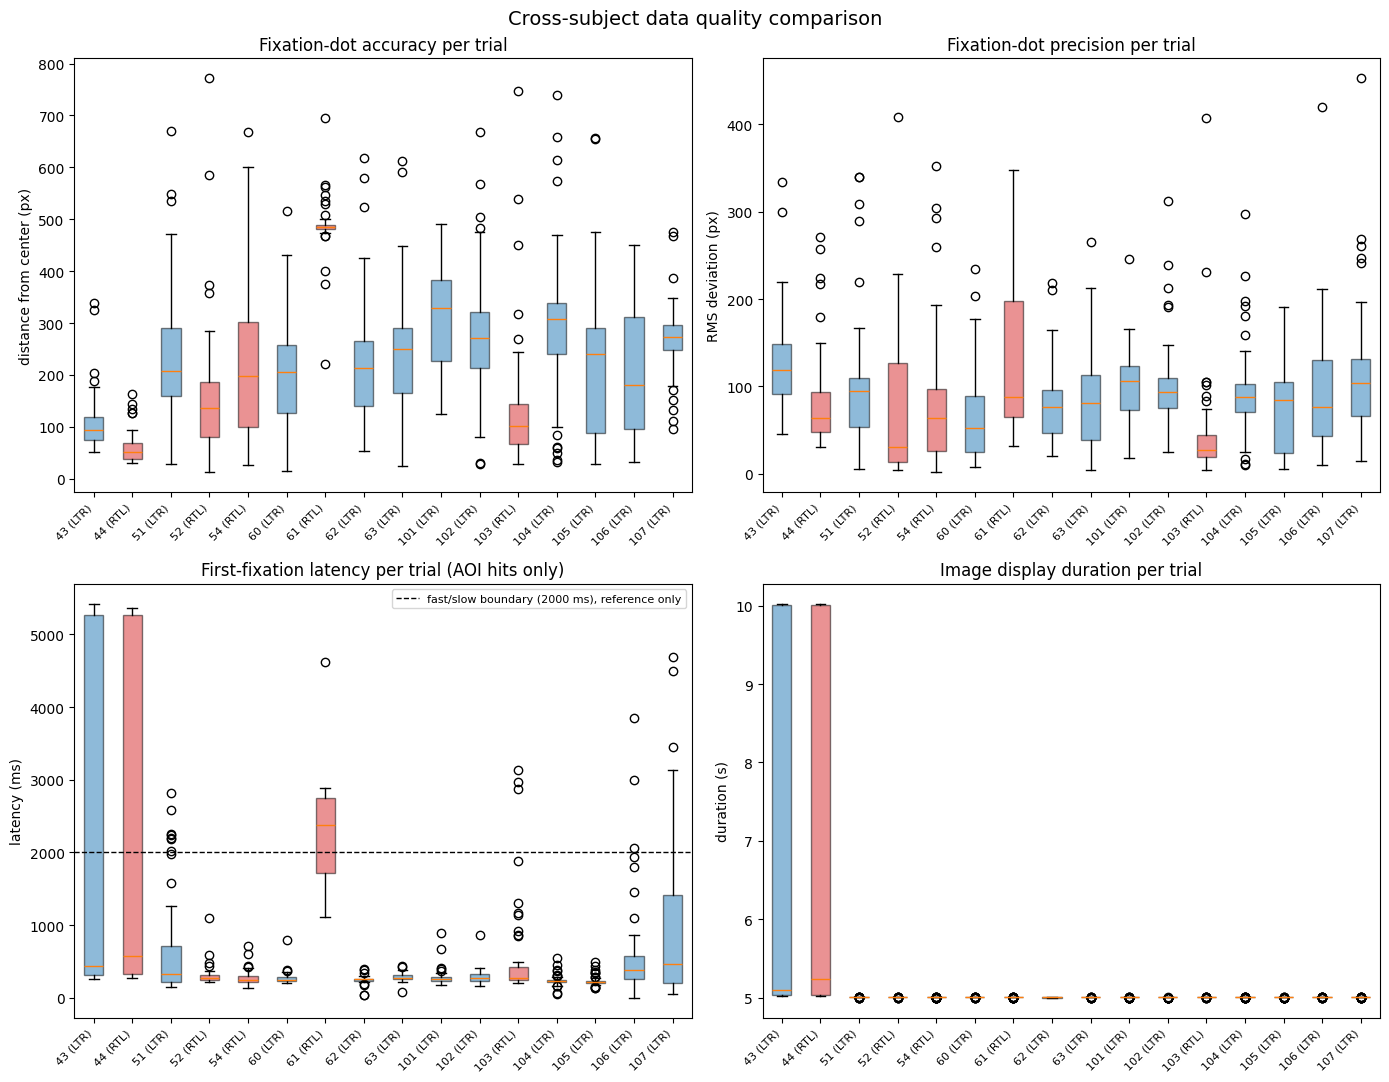

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

labels = [f"{s.split('-')[1]} ({GROUPS[s]})" for s in SUBJECTS]
colors = [GROUP_COLORS[GROUPS[s]] for s in SUBJECTS]


def styled_boxplot(ax, data_by_subject, title, ylabel, hline=None):
    data = [data_by_subject[s] for s in SUBJECTS]
    bp = ax.boxplot(data, tick_labels=labels, patch_artist=True)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.5)
    if hline is not None:
        ax.axhline(hline, color="black", linestyle="--", linewidth=1,
                    label=f"fast/slow boundary ({hline:.0f} ms), reference only")
        ax.legend(fontsize=8)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")


# (a) fixation-dot accuracy
acc_by_subj = {s: fixdot_rows[s]["accuracy_px"].dropna().values for s in SUBJECTS}
styled_boxplot(axes[0, 0], acc_by_subj, "Fixation-dot accuracy per trial", "distance from center (px)")

# (b) fixation-dot precision
prec_by_subj = {s: fixdot_rows[s]["precision_px"].dropna().values for s in SUBJECTS}
styled_boxplot(axes[0, 1], prec_by_subj, "Fixation-dot precision per trial", "RMS deviation (px)")

# (c) first-fixation latency (AOI hits only)
lat_by_subj = {s: first_fix.loc[(first_fix["subject"] == s) & first_fix["hit"], "latency_ms"].dropna().values
               for s in SUBJECTS}
styled_boxplot(axes[1, 0], lat_by_subj, "First-fixation latency per trial (AOI hits only)",
               "latency (ms)", hline=SLOW_REF_MS)

# (d) image display duration
dur_by_subj = {s: trial_durations[s] for s in SUBJECTS}
styled_boxplot(axes[1, 1], dur_by_subj, "Image display duration per trial", "duration (s)")

fig.suptitle("Cross-subject data quality comparison", fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "qc_boxplots.png"), dpi=150)
plt.show()

### Per-subject data-quality summary table

Same per-trial `accuracy_px` / `precision_px` values behind the boxplots
above (panels a and b), collapsed to one row per subject: usable trial
count, and median +/- IQR (75th - 25th percentile) for accuracy and
precision. Sorted by accuracy median, descending (worst calibration
accuracy first). Flags subjects showing a "calibration-offset" pattern:
tight, stable gaze estimates (precision median and IQR both at or below
the cross-subject median) that are nonetheless consistently off-target
(accuracy median above the cross-subject median of accuracy medians).

In [9]:
rows = []
for s in SUBJECTS:
    df = fixdot_rows[s]
    acc = df["accuracy_px"].dropna()
    prec = df["precision_px"].dropna()
    rows.append(dict(
        subject=s,
        group=GROUPS[s],
        n_trials=int(acc.shape[0]),
        acc_med_px=acc.median(),
        acc_iqr_px=acc.quantile(0.75) - acc.quantile(0.25),
        prec_med_px=prec.median(),
        prec_iqr_px=prec.quantile(0.75) - prec.quantile(0.25),
    ))

subj_quality = pd.DataFrame(rows).sort_values("acc_med_px", ascending=False).reset_index(drop=True)

display_df = subj_quality.copy()
for col in ["acc_med_px", "acc_iqr_px", "prec_med_px", "prec_iqr_px"]:
    display_df[col] = display_df[col].map(lambda v: f"{v:.1f}")

print(display_df.to_string(index=False))

acc_med_cross = subj_quality["acc_med_px"].median()
prec_med_cross = subj_quality["prec_med_px"].median()
prec_iqr_cross = subj_quality["prec_iqr_px"].median()

print()
print("Calibration-offset criterion: precision median <= cross-subject median "
      f"({prec_med_cross:.1f} px) AND precision IQR <= cross-subject median "
      f"({prec_iqr_cross:.1f} px) AND accuracy median > cross-subject median of "
      f"accuracy medians ({acc_med_cross:.1f} px).")

flagged = subj_quality[
    (subj_quality["prec_med_px"] <= prec_med_cross)
    & (subj_quality["prec_iqr_px"] <= prec_iqr_cross)
    & (subj_quality["acc_med_px"] > acc_med_cross)
]

if len(flagged):
    print("Flagged subjects (calibration-offset pattern):", ", ".join(flagged["subject"].tolist()))
else:
    print("Flagged subjects (calibration-offset pattern): none")


    subject group  n_trials acc_med_px acc_iqr_px prec_med_px prec_iqr_px
 subject-61   RTL        48      485.5        8.0        87.9       133.5
subject-101   LTR        48      329.0      156.1       106.6        49.9
subject-104   LTR        48      307.1       97.0        87.3        32.5
subject-107   LTR        48      273.7       46.9       104.3        64.9
subject-102   LTR        48      271.9      107.2        93.9        34.4
 subject-63   LTR        48      250.2      126.1        81.0        75.2
subject-105   LTR        49      240.0      201.7        83.9        80.8
 subject-62   LTR        48      212.9      124.8        76.4        48.7
 subject-51   LTR        48      207.1      131.9        94.5        56.2
 subject-60   LTR        48      205.5      131.2        52.3        64.0
 subject-54   RTL        48      198.3      201.2        63.9        70.6
subject-106   LTR        48      181.3      214.8        76.3        86.9
 subject-52   RTL        48      136.3

### Standalone accuracy boxplot (for slides)

Same data as panel (a) above, exported as a single figure so the
presentation can show just the calibration-accuracy comparison.

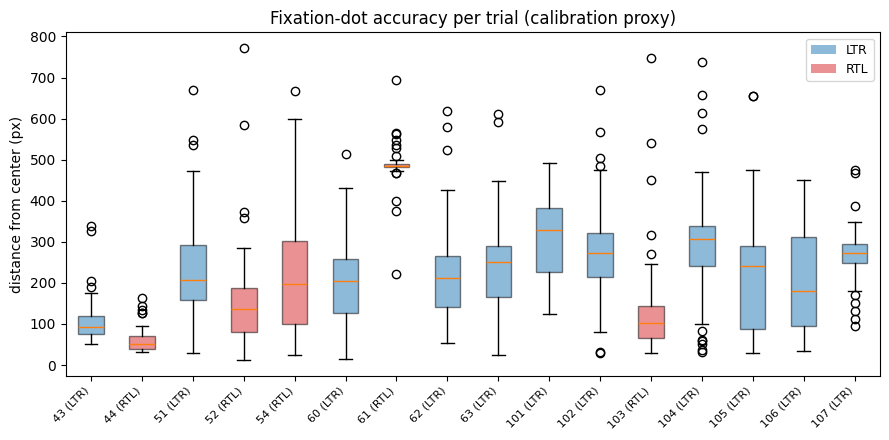

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
styled_boxplot(ax, acc_by_subj, "Fixation-dot accuracy per trial (calibration proxy)",
               "distance from center (px)")
handles = [patches.Patch(facecolor=GROUP_COLORS[g], alpha=0.5, label=g) for g in ("LTR", "RTL")]
ax.legend(handles=handles, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "qc_accuracy_boxplot.png"), dpi=150)
plt.show()

### Spatial offset scatter (x/y)

Same fixation-dot windows as above, but keeping the direction of the
error: per trial, the mean valid `BPOG` position minus the dot position
(screen center), in px. Small dots are trials, large ones subject means,
colored by group. Screen convention: positive y is down. Dotted circles
at 100/200/300 px; axes clipped at the 98th percentile of absolute
offsets, so a few extreme trials fall outside.

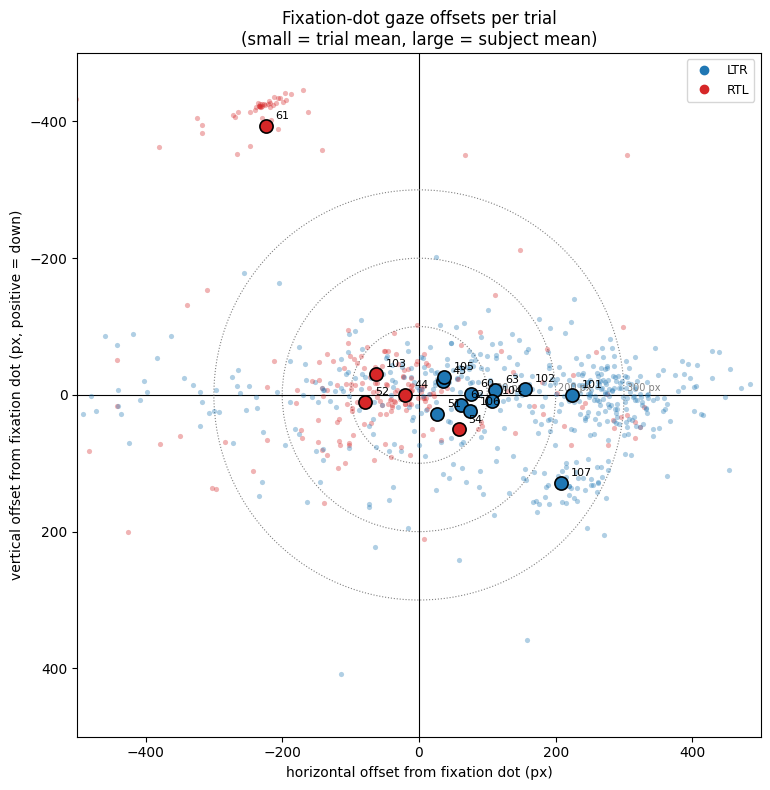

,dx,dy
subject,,
subject-43,34.6,-20.9
subject-44,-20.3,-0.0
subject-51,26.9,28.5
subject-52,-78.6,10.7
subject-54,58.0,50.6
subject-60,76.0,-1.2
subject-61,-223.7,-393.6
subject-62,61.4,15.3
subject-63,111.9,-7.5


In [11]:
offset_rows = []
for s in SUBJECTS:
    tsv = tsv_data[s]
    for i, (t0, t1) in enumerate(fixation_dot_windows(s), start=1):
        win = tsv[(tsv["TIME"] >= t0) & (tsv["TIME"] <= t1) & (tsv["BPOGV"] == 1)
                  & tsv["BPOGX"].between(0, 1) & tsv["BPOGY"].between(0, 1)]
        if len(win) == 0:
            continue
        offset_rows.append(dict(subject=s, trial=i,
                                dx=win["BPOGX"].mean() * SCREEN_W - cx,
                                dy=win["BPOGY"].mean() * SCREEN_H - cy))
offsets = pd.DataFrame(offset_rows)

fig, ax = plt.subplots(figsize=(8, 8))
lim = max(300, math.ceil(np.percentile(offsets[["dx", "dy"]].abs().values, 98) / 100) * 100)
for s in SUBJECTS:
    sub = offsets[offsets["subject"] == s]
    c = GROUP_COLORS[GROUPS[s]]
    ax.scatter(sub["dx"], sub["dy"], s=14, color=c, alpha=0.35, linewidths=0, zorder=2)
    ax.scatter(sub["dx"].mean(), sub["dy"].mean(), s=90, color=c, edgecolor="black",
               linewidth=1.2, zorder=4)
    ax.annotate(s.split("-")[1], (sub["dx"].mean(), sub["dy"].mean()),
                textcoords="offset points", xytext=(7, 5), fontsize=8, zorder=5)

ax.axhline(0, color="black", linewidth=0.8, zorder=1)
ax.axvline(0, color="black", linewidth=0.8, zorder=1)
for r in (100, 200, 300):
    ax.add_patch(plt.Circle((0, 0), r, fill=False, color="gray", linestyle=":",
                            linewidth=0.8, zorder=1))
    ax.annotate(f"{r} px", (r, 0), textcoords="offset points", xytext=(2, 3),
                fontsize=7, color="gray")

ax.set_xlim(-lim, lim)
ax.set_ylim(lim, -lim)  # y inverted to match screen convention
ax.set_aspect("equal")
ax.set_xlabel("horizontal offset from fixation dot (px)")
ax.set_ylabel("vertical offset from fixation dot (px, positive = down)")
ax.set_title("Fixation-dot gaze offsets per trial\n(small = trial mean, large = subject mean)")
handles = [Line2D([], [], marker="o", linestyle="", color=GROUP_COLORS[g], label=g)
           for g in ("LTR", "RTL")]
ax.legend(handles=handles, fontsize=9, loc="upper right")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "qc_fixdot_xy_scatter.png"), dpi=150)
plt.show()

offsets.groupby("subject")[["dx", "dy"]].mean().round(1).reindex(SUBJECTS)

### All samples pooled (x/y scatter, all trials & subjects)

Every valid raw gaze sample (`BPOGV == 1`, `BPOGX`/`BPOGY` in [0, 1]) from every stimulus
window (`STIMULUS_ONSET` -> next `IMAGE_OFFSET`) of all 16 subjects, pooled into a single
scatter in screen pixels. Not meant to be pretty -- just a raw sanity-check of overall
gaze coverage across the whole dataset.

Total pooled samples: 568508


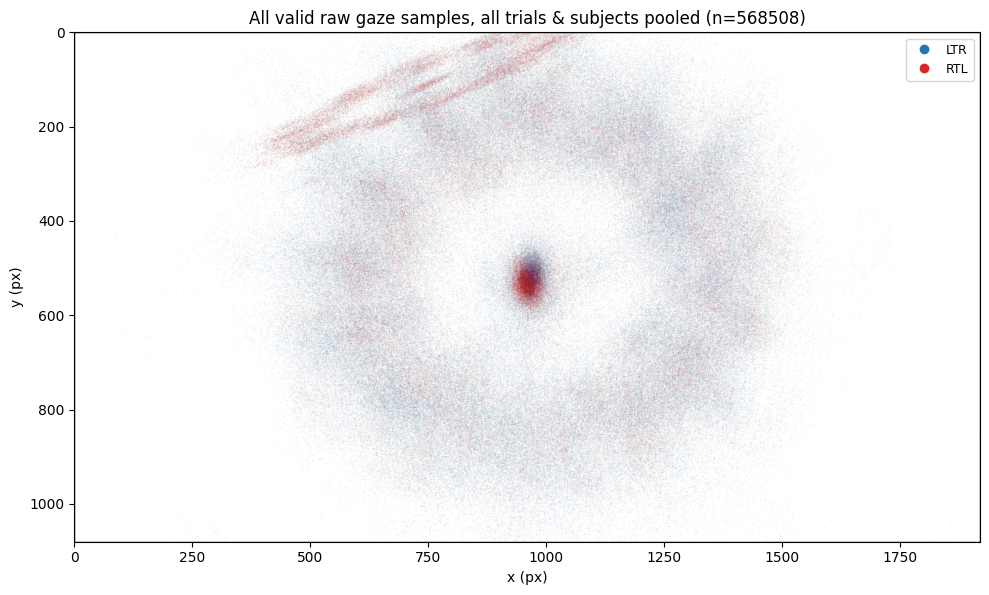

In [12]:
all_x, all_y, all_group = [], [], []
for s in SUBJECTS:
    tsv = tsv_data[s]
    u = tsv["USER"].astype(str)
    onsets = tsv.loc[tsv["USER"].notna() & u.str.contains("STIMULUS_ONSET", na=False), "TIME"].values
    offsets = tsv.loc[tsv["USER"].notna() & u.str.contains("IMAGE_OFFSET", na=False), "TIME"].values
    for t0 in onsets:
        later = offsets[offsets > t0]
        if len(later) == 0:
            continue
        t1 = later[0]
        win = tsv[(tsv["TIME"] >= t0) & (tsv["TIME"] <= t1) & (tsv["BPOGV"] == 1)
                  & tsv["BPOGX"].between(0, 1) & tsv["BPOGY"].between(0, 1)]
        if len(win) == 0:
            continue
        all_x.append(win["BPOGX"].values * SCREEN_W)
        all_y.append(win["BPOGY"].values * SCREEN_H)
        all_group.append(np.full(len(win), GROUPS[s]))

all_x = np.concatenate(all_x)
all_y = np.concatenate(all_y)
all_group = np.concatenate(all_group)

print(f"Total pooled samples: {len(all_x)}")

fig, ax = plt.subplots(figsize=(10, 6))
for g in ("LTR", "RTL"):
    mask = all_group == g
    ax.scatter(all_x[mask], all_y[mask], s=1, color=GROUP_COLORS[g], alpha=0.03,
               linewidths=0, zorder=2, label=g)

ax.add_patch(patches.Rectangle((0, 0), SCREEN_W, SCREEN_H, edgecolor="black",
                                facecolor="none", linewidth=1, zorder=1))
ax.set_xlim(0, SCREEN_W)
ax.set_ylim(SCREEN_H, 0)  # y inverted to match screen convention
ax.set_aspect("equal")
ax.set_xlabel("x (px)")
ax.set_ylabel("y (px)")
ax.set_title(f"All valid raw gaze samples, all trials & subjects pooled (n={len(all_x)})")
handles = [Line2D([], [], marker="o", linestyle="", color=GROUP_COLORS[g], label=g)
           for g in ("LTR", "RTL")]
ax.legend(handles=handles, fontsize=9, loc="upper right")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "qc_all_samples_xy_scatter.png"), dpi=150)
plt.show()

### AOI schematic (for slides)

One trial's stimulus layout drawn to scale on the 1920x1080 screen,
with the +-150 px AOI squares and the distances annotated. Stimulus
images come straight out of the experiment file's pool, at the same
on-screen size the experiment uses (1025 px png at scale 0.25 = ~256 px).
Arrangement 10-4 o'clock, offsets from the logged trial coordinates.

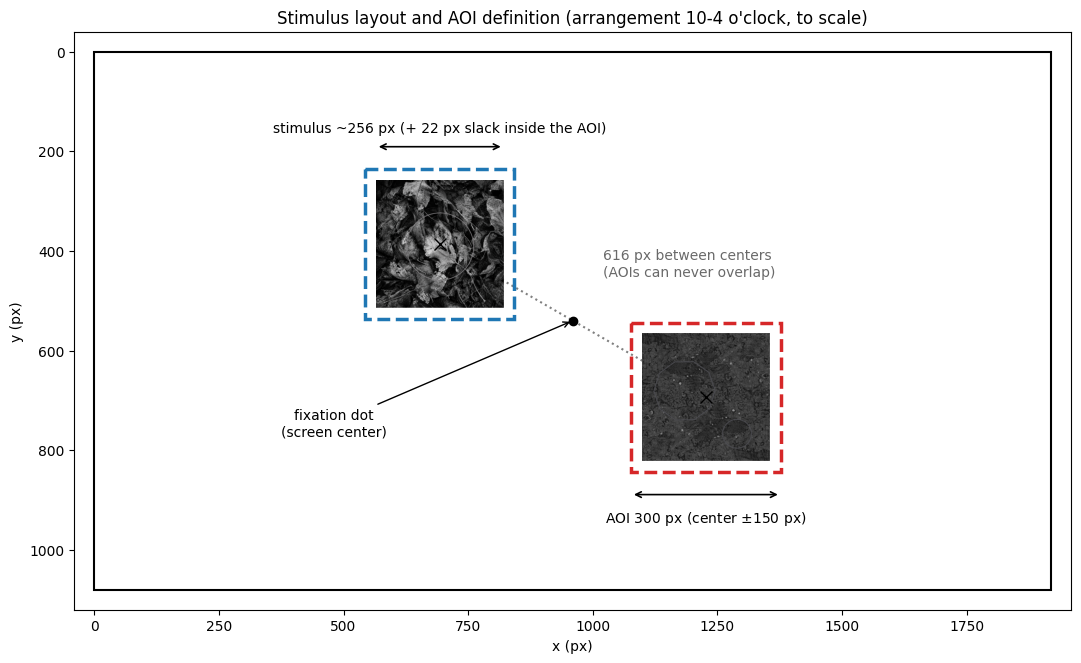

In [13]:
import tarfile
import io
from PIL import Image

with tarfile.open("../src/V7_AttentionalSpatialBias_.osexp") as t:
    img_a = np.asarray(Image.open(io.BytesIO(t.extractfile("pool/000.png").read())))
    img_b = np.asarray(Image.open(io.BytesIO(t.extractfile("pool/001.png").read())))

STIM_HALF = 128          # ~256 px on screen (1025 px png at scale 0.25)
CX, CY = SCREEN_W / 2, SCREEN_H / 2
# arrangement "2" = 10-4 o'clock, offsets as logged in the trial CSVs
OFF_L, OFF_R = (-267, -154), (267, 154)

fig, ax = plt.subplots(figsize=(11, 6.6))
ax.set_xlim(-40, SCREEN_W + 40)
ax.set_ylim(SCREEN_H + 40, -40)
ax.set_aspect("equal")
ax.add_patch(patches.Rectangle((0, 0), SCREEN_W, SCREEN_H, fill=False,
                               edgecolor="black", linewidth=1.5))

for (dx, dy), img, col, name in [(OFF_L, img_a, "#1f77b4", "stimulus A"),
                                  (OFF_R, img_b, "#d62728", "stimulus B")]:
    cx, cy = CX + dx, CY + dy
    ax.imshow(img, extent=(cx - STIM_HALF, cx + STIM_HALF,
                           cy + STIM_HALF, cy - STIM_HALF), zorder=2)
    ax.add_patch(patches.Rectangle((cx - AOI_MARGIN_PX, cy - AOI_MARGIN_PX),
                                   2 * AOI_MARGIN_PX, 2 * AOI_MARGIN_PX,
                                   fill=False, edgecolor=col, linewidth=2.5,
                                   linestyle="--", zorder=3))
    ax.plot(cx, cy, "x", color="black", markersize=8, zorder=4)

# fixation dot at screen center
ax.plot(CX, CY, "o", color="black", markersize=6, zorder=4)
ax.annotate("fixation dot\n(screen center)", (CX, CY), xytext=(CX - 480, CY + 230),
            textcoords="data", fontsize=10, ha="center",
            arrowprops=dict(arrowstyle="->", linewidth=1))

# AOI width annotation, under the right stimulus
cxr, cyr = CX + OFF_R[0], CY + OFF_R[1]
y_arrow = cyr + AOI_MARGIN_PX + 45
ax.annotate("", xy=(cxr - AOI_MARGIN_PX, y_arrow), xytext=(cxr + AOI_MARGIN_PX, y_arrow),
            arrowprops=dict(arrowstyle="<->", linewidth=1.2))
ax.text(cxr, y_arrow + 55, "AOI 300 px (center $\pm$150 px)", ha="center", fontsize=10)

# stimulus width annotation, above the left stimulus
cxl, cyl = CX + OFF_L[0], CY + OFF_L[1]
y_arrow2 = cyl - AOI_MARGIN_PX - 45
ax.annotate("", xy=(cxl - STIM_HALF, y_arrow2), xytext=(cxl + STIM_HALF, y_arrow2),
            arrowprops=dict(arrowstyle="<->", linewidth=1.2))
ax.text(cxl, y_arrow2 - 30, "stimulus ~256 px (+ 22 px slack inside the AOI)",
        ha="center", fontsize=10)

# center-to-center distance
ax.plot([cxl, cxr], [cyl, cyr], linestyle=":", color="gray", linewidth=1.5, zorder=1)
ax.text(CX + 60, CY - 90, "616 px between centers\n(AOIs can never overlap)",
        fontsize=10, color="dimgray")

ax.set_title("Stimulus layout and AOI definition (arrangement 10-4 o'clock, to scale)")
ax.set_xlabel("x (px)")
ax.set_ylabel("y (px)")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "aoi_schematic.png"), dpi=150)
plt.show()

## 7. First-fixation yield per subject

Same exclusion logic as `attentional_spatial_bias.ipynb`: a trial is usable
if it has an AOI-hit first fixation with latency at or above
`MIN_LATENCY_MS`. There is no upper latency cutoff; the count of trials
slower than `SLOW_REF_MS` is shown for reference only, because those slow
trials cluster in arrangements without an upper-left stimulus.

In [14]:
yield_rows = []
for s in SUBJECTS:
    sub = first_fix[first_fix["subject"] == s]
    n_trials = len(sub)
    n_hit = int(sub["hit"].sum())
    n_too_fast = int(((sub["latency_ms"] < MIN_LATENCY_MS) & sub["hit"]).sum())
    n_too_slow = int(((sub["latency_ms"] > SLOW_REF_MS) & sub["hit"]).sum())  # info only
    n_surviving = int(((sub["latency_ms"] >= MIN_LATENCY_MS) & sub["hit"]).sum())
    yield_rows.append(dict(subject=s, n_trials=n_trials, n_aoi_hit=n_hit,
                            n_latency_lt_80ms=n_too_fast, n_latency_gt_2000ms=n_too_slow,
                            n_surviving=n_surviving))

yield_table = pd.DataFrame(yield_rows)
total_surviving = yield_table["n_surviving"].sum()
total_trials = yield_table["n_trials"].sum()
print(yield_table.to_string(index=False))
print(f"\nOverall usable trials: {total_surviving}/{total_trials}")

    subject  n_trials  n_aoi_hit  n_latency_lt_80ms  n_latency_gt_2000ms  n_surviving
 subject-43        48         48                  0                   18           48
 subject-44        48         48                  0                   18           48
 subject-51        48         48                  0                    7           48
 subject-52        48         48                  0                    0           48
 subject-54        48         48                  0                    0           48
 subject-60        48         48                  0                    0           48
 subject-61        48          8                  0                    5            8
 subject-62        48         48                  2                    0           46
 subject-63        48         48                  0                    0           48
subject-101        48         48                  0                    0           48
subject-102        48         48                  0   

## 8. Scanpath plots per subject

One 2x3 grid per subject, one trial per position code. Raw gaze trajectory
during the stimulus window, colored by time since onset (viridis), with the
two AOI squares (left blue, right red), stimulus centers (x), and screen
center (+). Axes fixed to the full screen, y-axis inverted to match screen
convention.

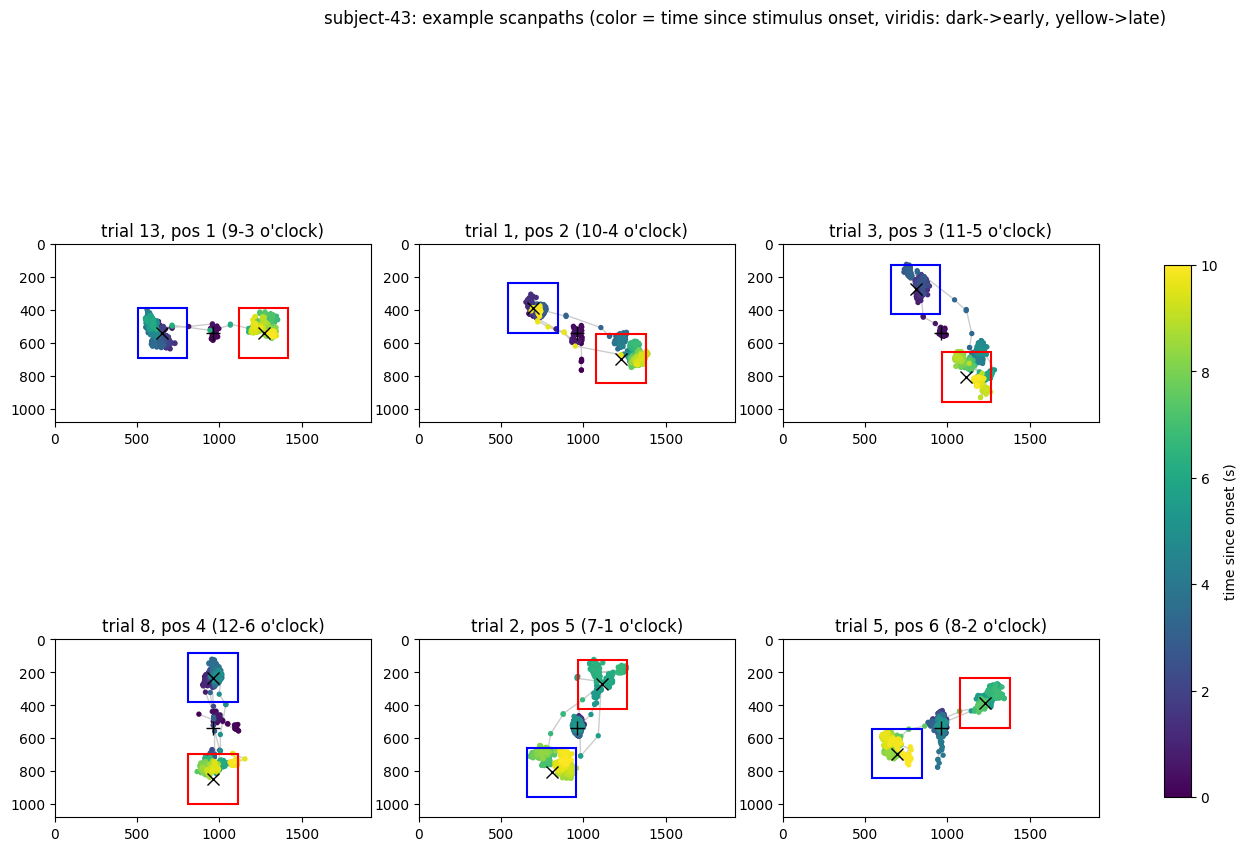

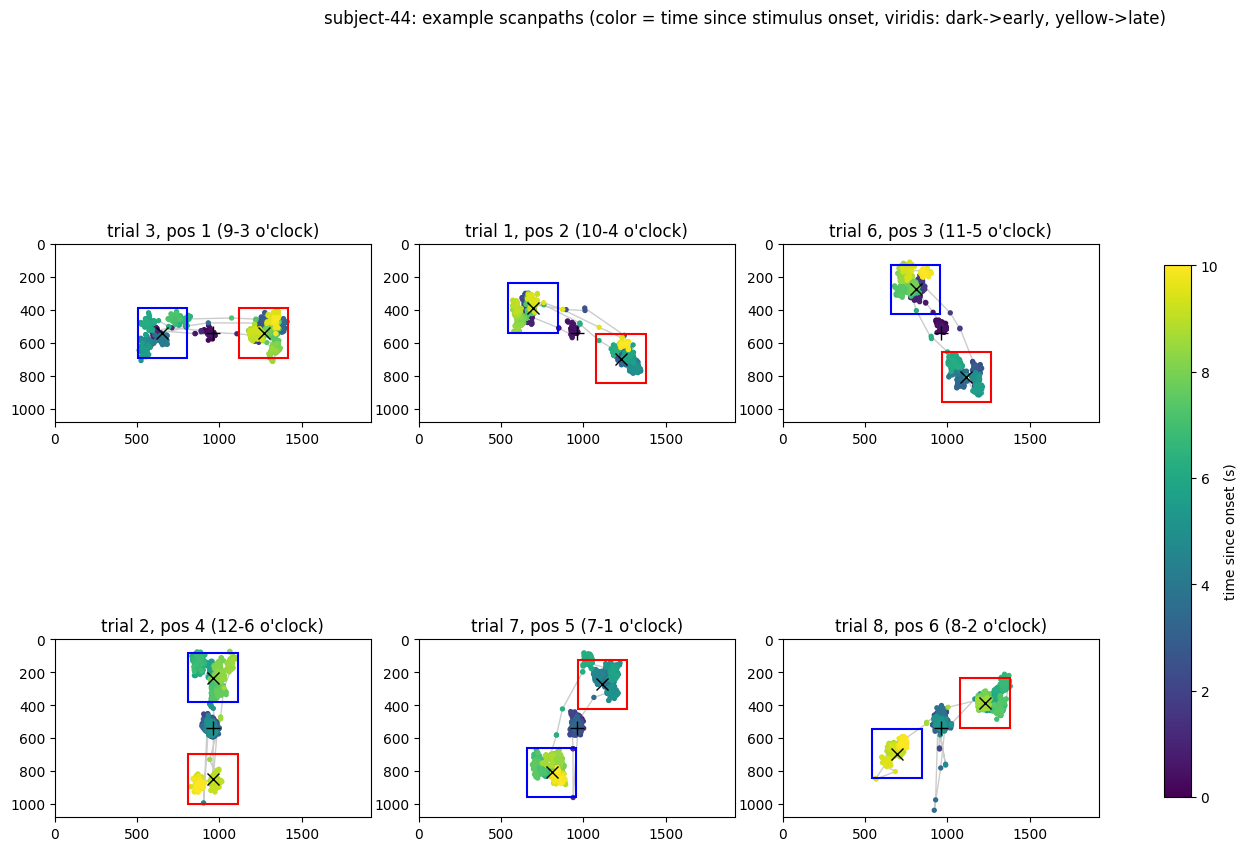

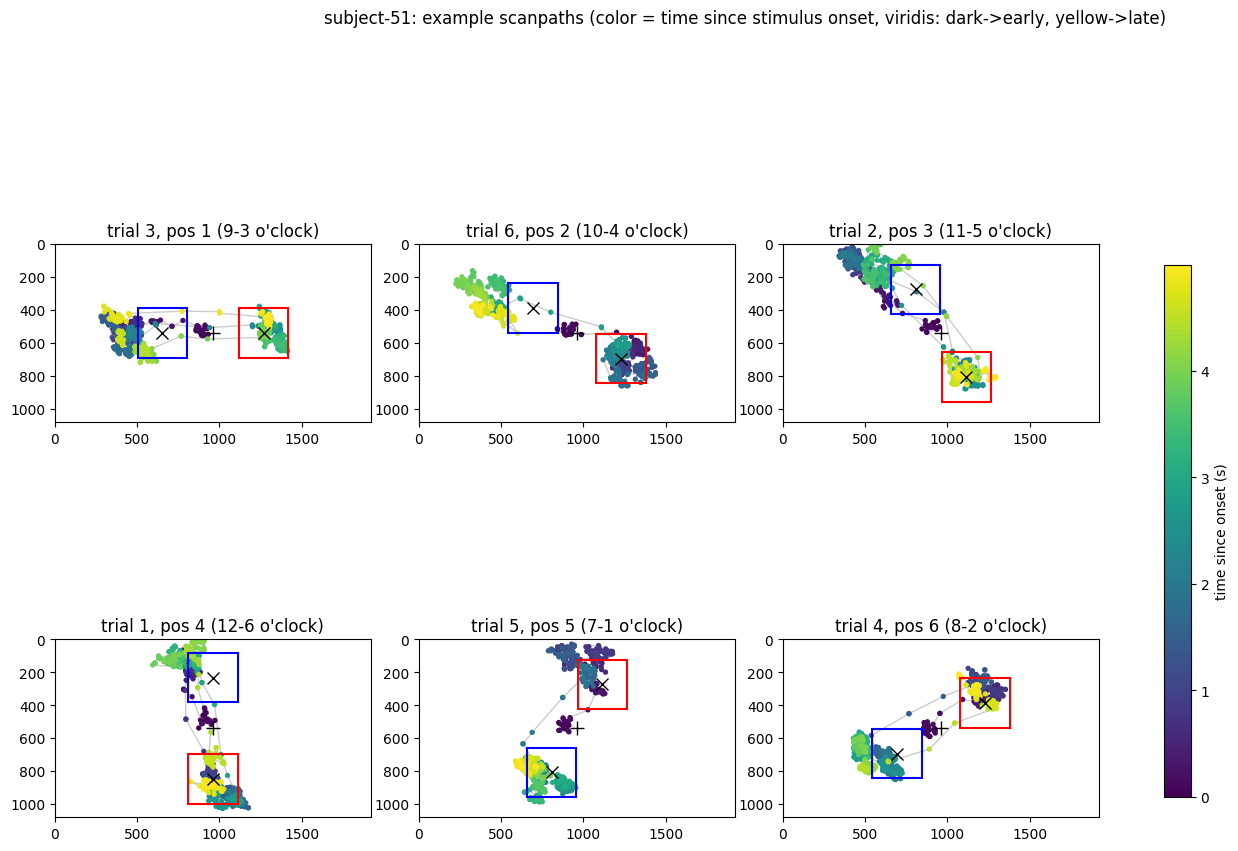

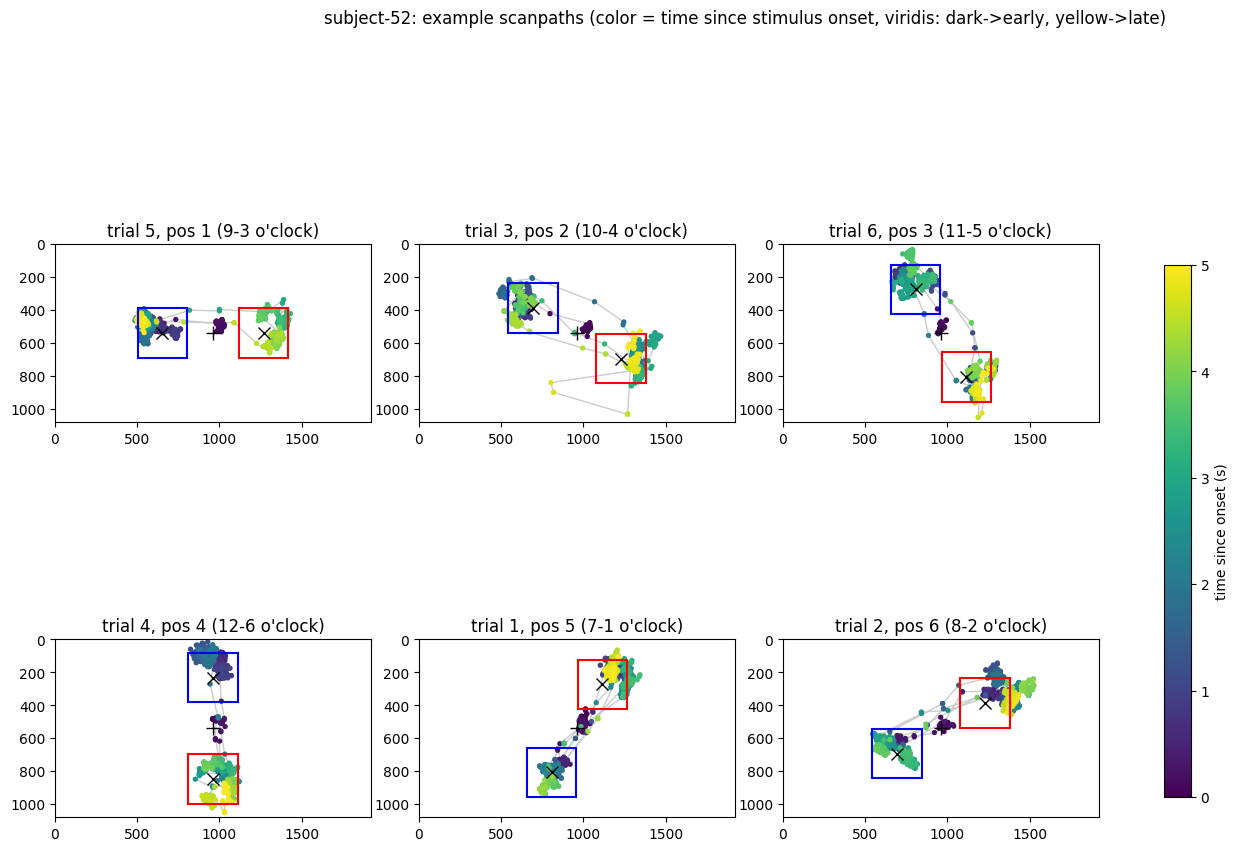

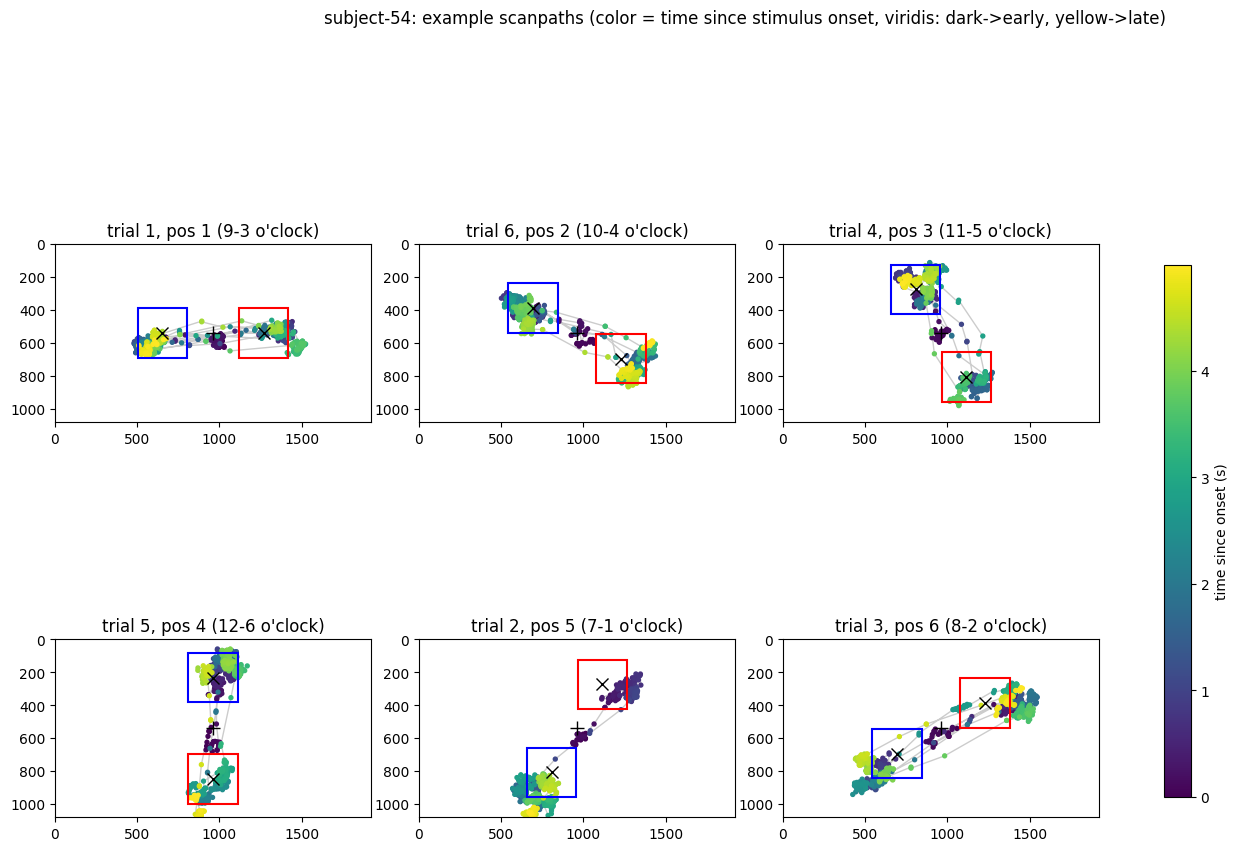

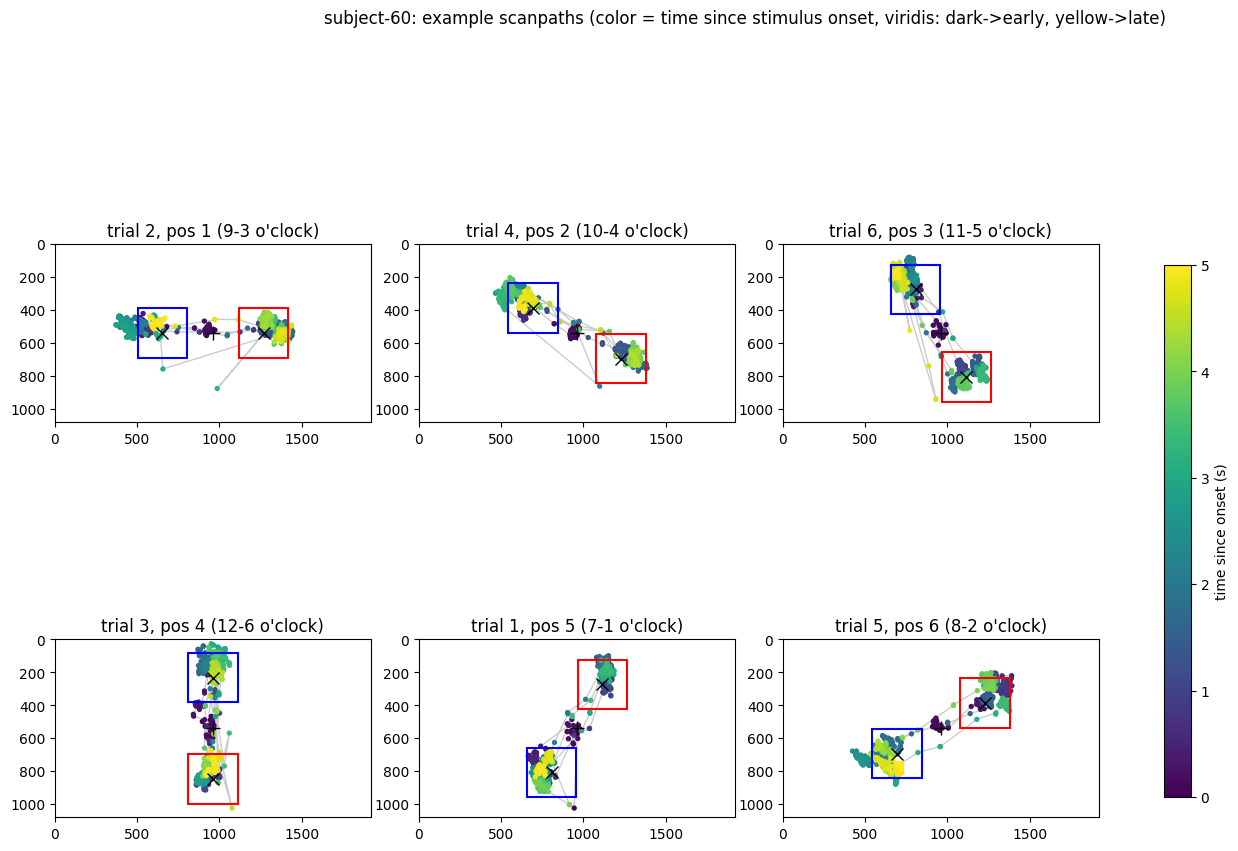

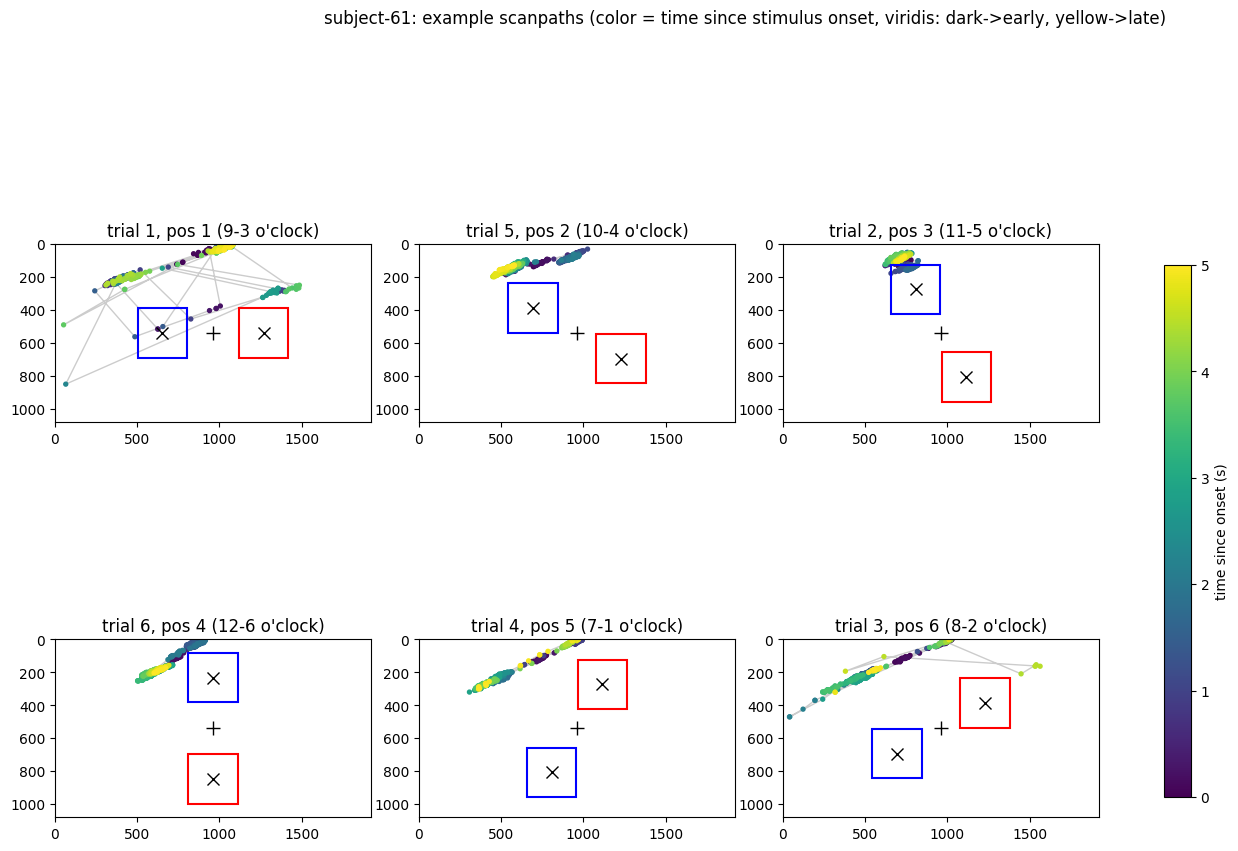

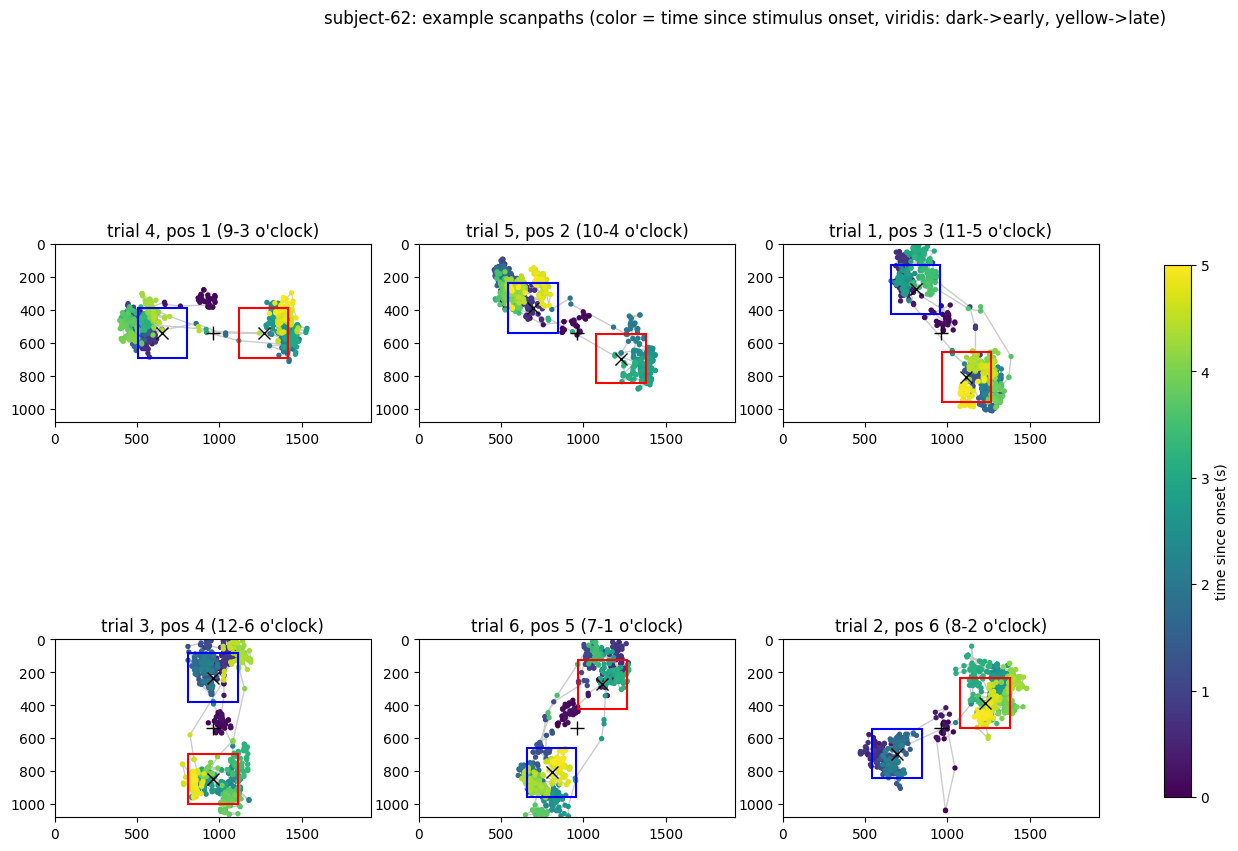

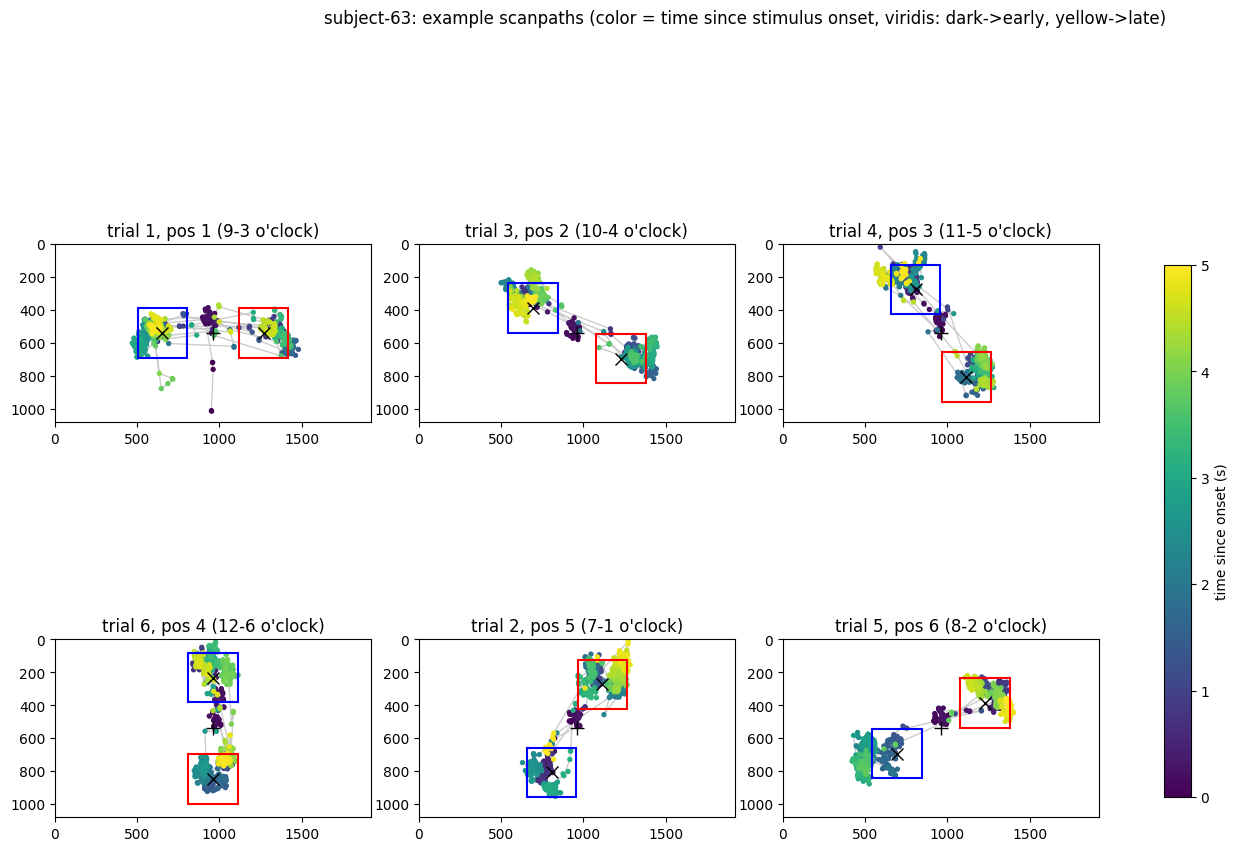

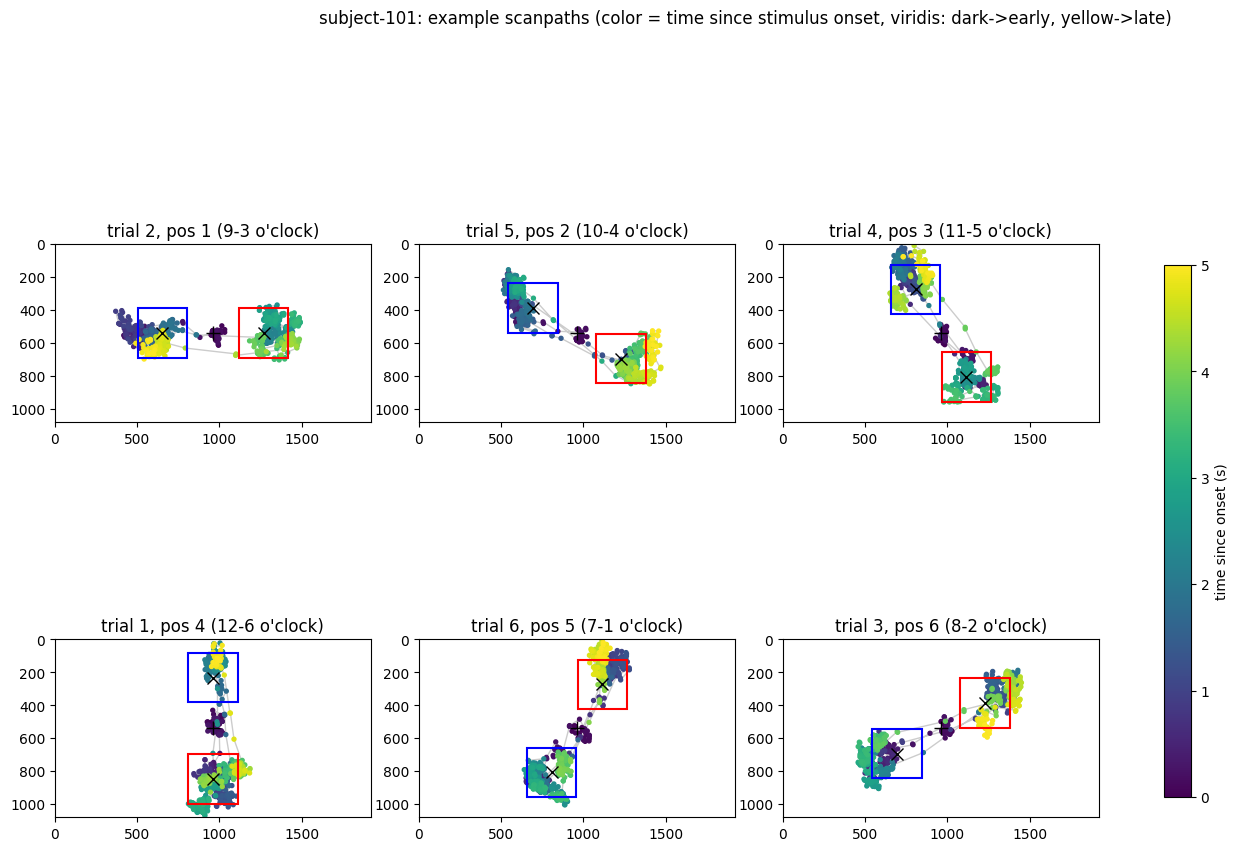

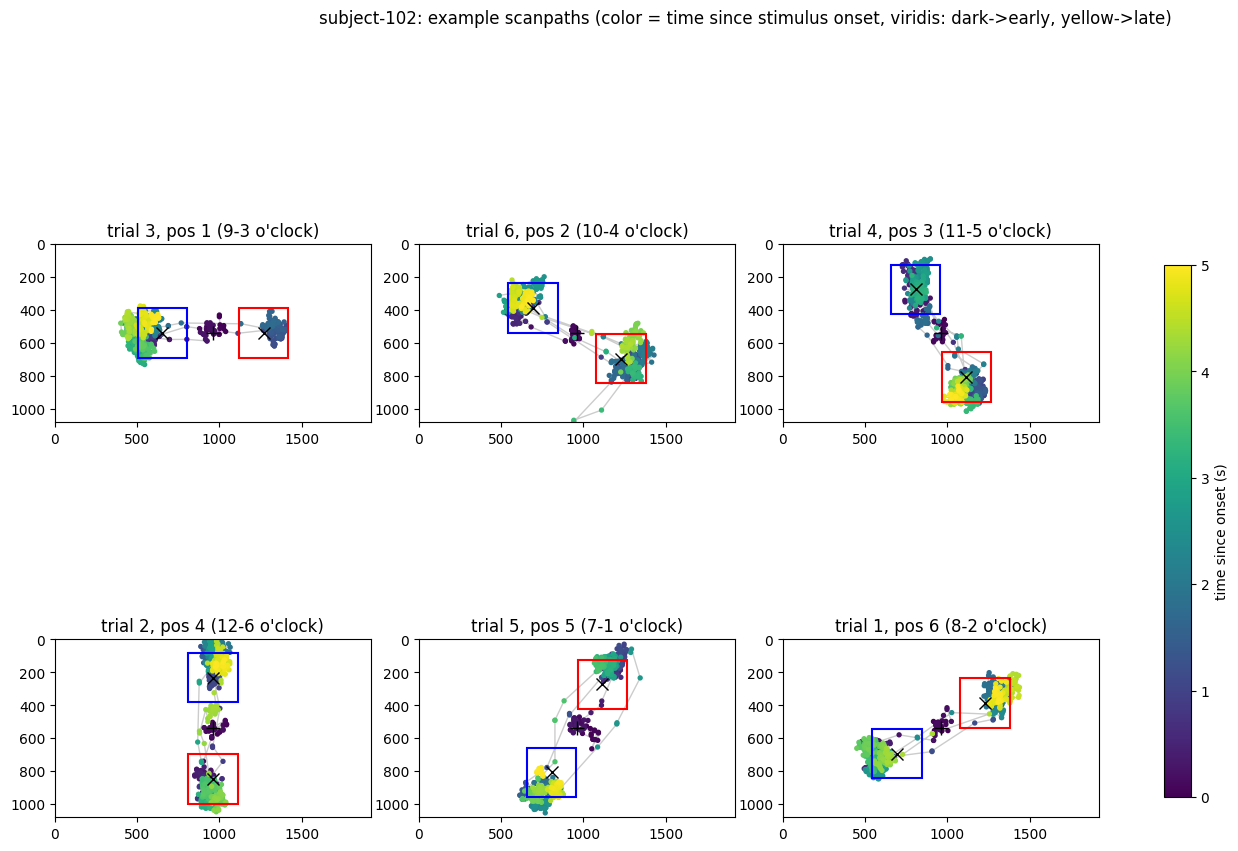

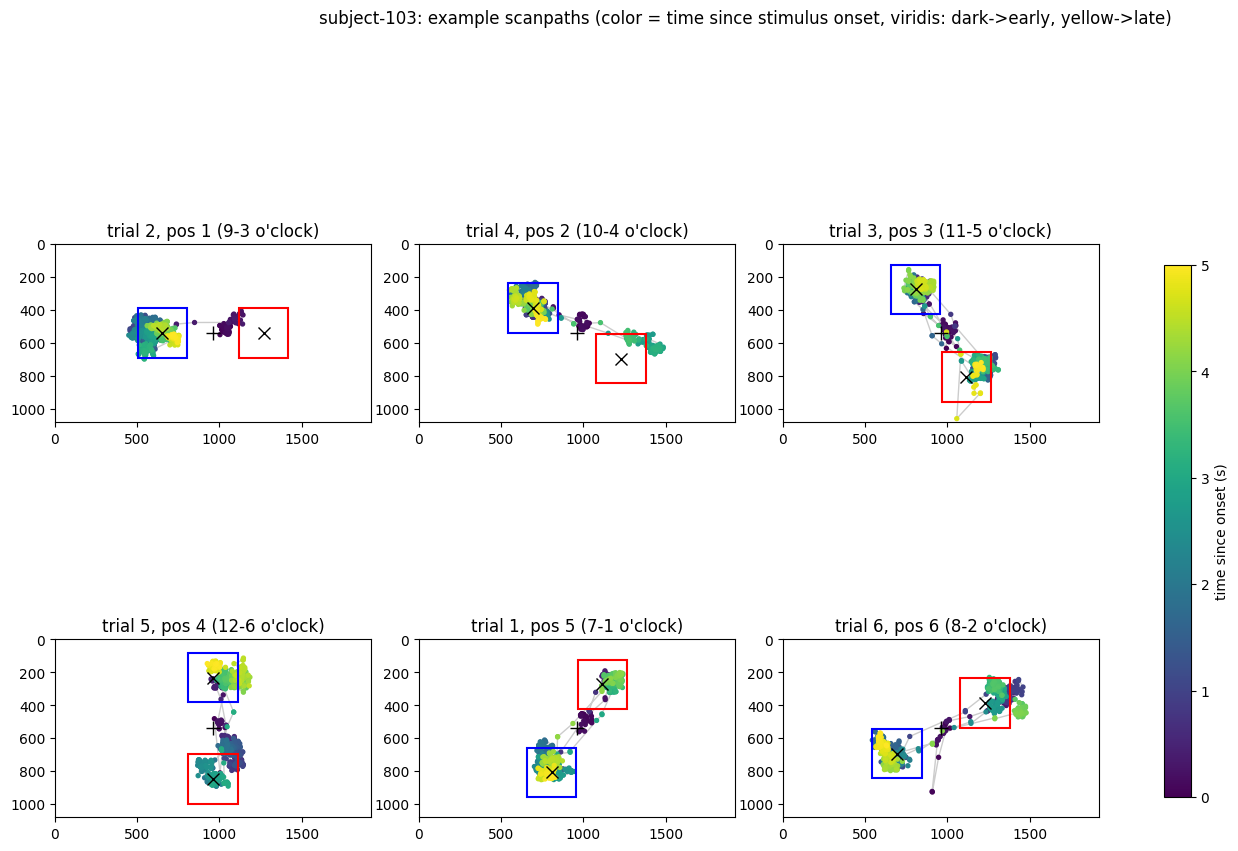

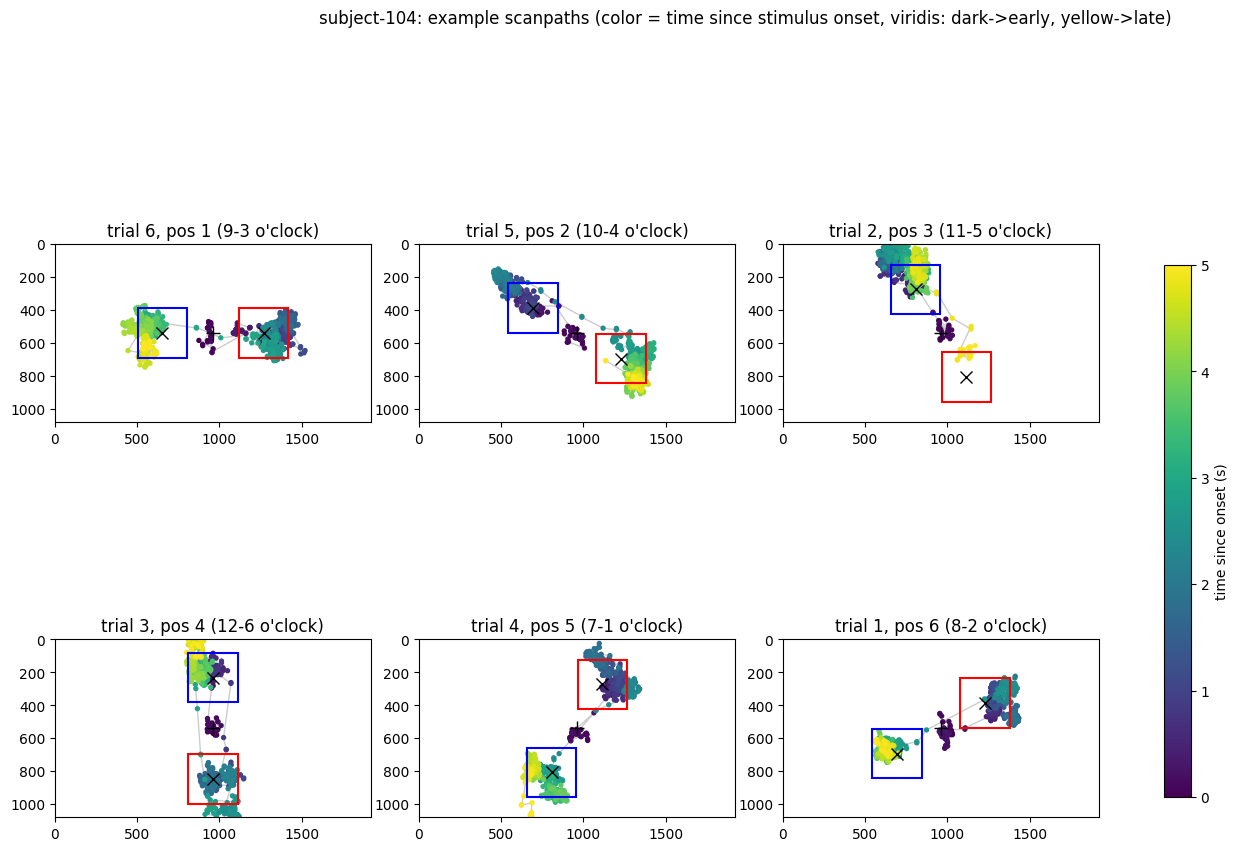

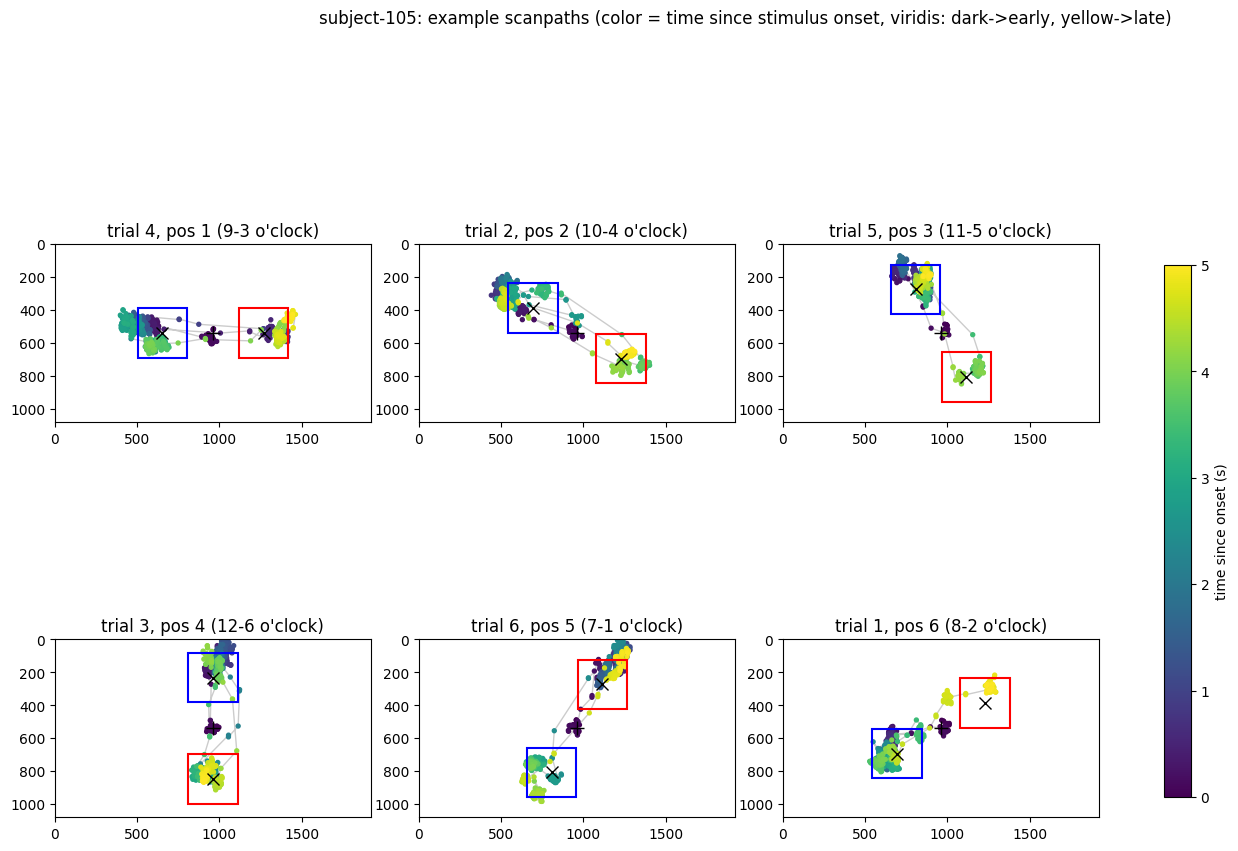

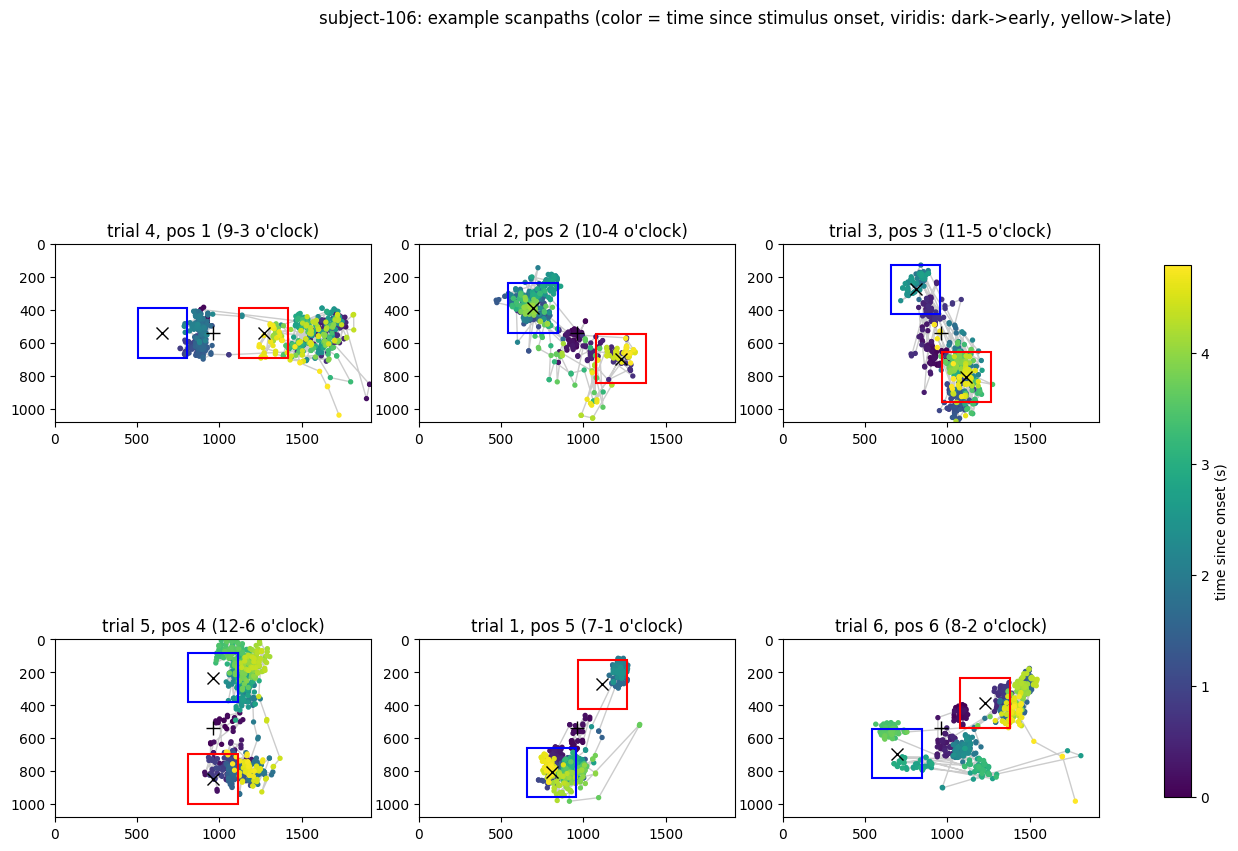

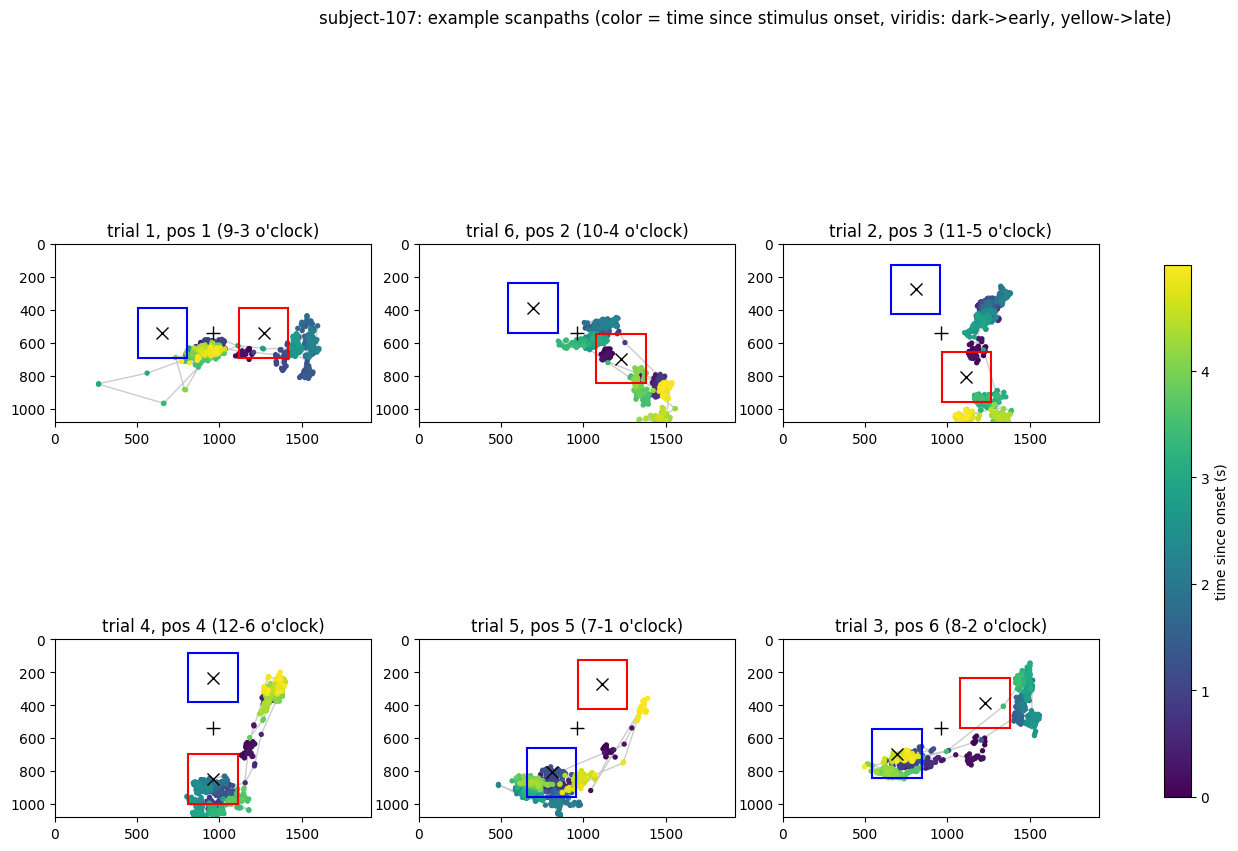

In [15]:
def plot_subject_scanpaths(subj):
    tsv = tsv_data[subj]
    csvdf = csv_data[subj].sort_values("trial_nr").reset_index(drop=True)

    u = tsv["USER"].astype(str)
    onsets = tsv.loc[tsv["USER"].notna() & u.str.contains("STIMULUS_ONSET", na=False), "TIME"].values
    offsets = tsv.loc[tsv["USER"].notna() & u.str.contains("IMAGE_OFFSET", na=False), "TIME"].values

    # pick the first trial (in trial_nr order) seen at each position code
    example_trials = {}
    for idx, trial in csvdf.iterrows():
        pos = str(trial["position"])
        if pos not in example_trials:
            example_trials[pos] = idx

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    sm = None
    for ax, pos in zip(axes.flat, sorted(example_trials, key=int)):
        idx = example_trials[pos]
        trial = csvdf.loc[idx]
        t0 = onsets[idx]
        later = offsets[offsets > t0]
        t_end = later[0] if len(later) else t0 + 10.0

        win = tsv[(tsv["TIME"] >= t0) & (tsv["TIME"] <= t_end) & (tsv["BPOGV"] == 1)
                  & tsv["BPOGX"].between(0, 1) & tsv["BPOGY"].between(0, 1)]
        x = win["BPOGX"].values * SCREEN_W
        y = win["BPOGY"].values * SCREEN_H
        t_rel = win["TIME"].values - t0

        ax.plot(x, y, "-", color="gray", alpha=0.4, linewidth=1, zorder=1)
        sm = ax.scatter(x, y, c=t_rel, cmap="viridis", s=8, zorder=2)

        lx = SCREEN_W / 2 + trial["x_left"]
        ly = SCREEN_H / 2 + trial["y_left"]
        rx = SCREEN_W / 2 + trial["x_right"]
        ry = SCREEN_H / 2 + trial["y_right"]

        ax.add_patch(patches.Rectangle((lx - AOI_MARGIN_PX, ly - AOI_MARGIN_PX),
                                        2 * AOI_MARGIN_PX, 2 * AOI_MARGIN_PX,
                                        edgecolor="blue", facecolor="none", linewidth=1.5, zorder=3))
        ax.add_patch(patches.Rectangle((rx - AOI_MARGIN_PX, ry - AOI_MARGIN_PX),
                                        2 * AOI_MARGIN_PX, 2 * AOI_MARGIN_PX,
                                        edgecolor="red", facecolor="none", linewidth=1.5, zorder=3))
        ax.plot([lx, rx], [ly, ry], "x", color="black", markersize=8, zorder=4)
        ax.plot(SCREEN_W / 2, SCREEN_H / 2, "+", color="black", markersize=10, zorder=4)

        h1, h2 = POSITION_LABELS[pos]
        ax.set_title(f"trial {int(trial['trial_nr'])}, pos {pos} ({h1}-{h2} o'clock)")
        ax.set_xlim(0, SCREEN_W)
        ax.set_ylim(0, SCREEN_H)
        ax.invert_yaxis()
        ax.set_aspect("equal")

    fig.suptitle(f"{subj}: example scanpaths (color = time since stimulus onset, viridis: dark->early, yellow->late)",
                 fontsize=12)
    fig.tight_layout(rect=(0, 0, 0.92, 0.95))
    if sm is not None:
        fig.colorbar(sm, ax=axes, shrink=0.6, label="time since onset (s)")
    fig.savefig(os.path.join(OUT_DIR, f"qc_scanpaths_{subj}.png"), dpi=150)
    plt.show()


for s in SUBJECTS:
    plot_subject_scanpaths(s)

## 9. Summary

What to look for:

- Section 2: `status == "OK"` and durations near 5 s for every subject.
  Anything else means a logging glitch worth checking before including
  that subject.
- Section 3: low sampling rate, many >50 ms gaps, or low `FPOGV`/`BPOGV`
  validity point to tracking loss, not a behavioral effect.
- Section 4-5: accuracy well above ~100 px suggests calibration drift,
  and high precision values suggest noisy tracking even with good accuracy.
- Section 6: a subject whose box sits far from the others is worth a closer
  look at their scanpaths (Section 8).
- Section 7: much lower `n_surviving` than the rest, even with clean marker
  counts, is worth flagging.
- Section 8: gaze should land inside the AOIs on most trials, and the AOI
  squares should sit in sensible positions. Position `4` should show them
  above/below screen center, not left/right.